# **imports**

In [16]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch

# load **DATA**

In [13]:
def uniform_sampling(contour, n):
    contour = np.asarray(contour, dtype=np.float32)

    if not np.allclose(contour[0], contour[-1]):
        contour = np.vstack([contour, contour[0]])

    # Segmentvektoren + Längen
    seg = np.diff(contour, axis=0)
    seg_len = np.linalg.norm(seg, axis=1)

    # kumulative Bogenlänge
    s = np.concatenate([[0], np.cumsum(seg_len)])

    # Zielpositionen
    t = np.linspace(0, s[-1], n, endpoint=False)

    # Segmentindex
    idx = np.searchsorted(s, t, side='right') - 1
    idx = np.clip(idx, 0, len(seg)-1)

    # lokale Interpolation
    local_t = (t - s[idx]) / seg_len[idx]

    return contour[idx] + seg[idx] * local_t[:, None]

In [ ]:
class PH2ContourDataset(Dataset):
    def __init__(self, base_path, n_punkte=200, img_size=(256, 256)):
        """
        base_path: Der Pfad zum Ordner "PH2 Dataset images" 
                   (z.B. "C:/Users/.../PH2Dataset/PH2 Dataset images")
        """
        self.base_path = base_path
        self.n_punkte = n_punkte
        self.img_size = img_size
        self.samples = []

        # 1. Die exakte Ordnerstruktur des PH2-Datasets auslesen
        for folder_name in os.listdir(base_path):
            folder_path = os.path.join(base_path, folder_name)
            
            # Überprüfen, ob es ein Ordner ist (z.B. "IMD002")
            if os.path.isdir(folder_path):
                # Die Pfade exakt nach der PH2-Namenskonvention zusammenbauen
                img_path = os.path.join(folder_path, f"{folder_name}_Dermoscopic_Image", f"{folder_name}.bmp")
                mask_path = os.path.join(folder_path, f"{folder_name}_lesion", f"{folder_name}_lesion.bmp")
                
                # Nur hinzufügen, wenn beide Dateien auch wirklich existieren
                if os.path.exists(img_path) and os.path.exists(mask_path):
                    self.samples.append({
                        'img_path': img_path,
                        'mask_path': mask_path
                    })

        print(f"Datensatz geladen: {len(self.samples)} Bilder und Masken gefunden.")

        # 2. PyTorch Transformationen für das Konditionierungs-Bild
        self.img_transform = transforms.Compose([
            transforms.Resize(img_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) 
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # --- A. BILD VERARBEITEN ---
        img = Image.open(sample['img_path']).convert("RGB")
        mask = Image.open(sample['mask_path']).convert("L") # Luminance (Graustufen)

        # WICHTIG: Bild und Maske auf die Zielgröße skalieren - Kontrolle damit alle auf der gleichen Größe sind!
        mask = mask.resize(self.img_size, Image.NEAREST)
        img_tensor = self.img_transform(img)

        # --- B. KONTUR EXTRAHIEREN ---
        mask_np = np.array(mask)
        mask_binary = (mask_np > 0).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        
        # Die größte Kontur nehmen (falls es kleine Störpixel in der Maske gibt)
        contour = max(contours, key=cv2.contourArea).squeeze()

        # DEINE FUNKTION: Punkte samplen (Kein Shuffle!)
        points = uniform_sampling(contour, self.n_punkte) 

        # --- C. KOORDINATEN NORMALISIEREN [-1, 1] ---
        W, H = self.img_size
        points_norm = points.astype(np.float32)
        
        points_norm[:, 0] = points_norm[:, 0] / (W - 1)
        points_norm[:, 1] = points_norm[:, 1] / (H - 1)
        
        points_norm = points_norm * 2.0 - 1.0

        points_tensor = torch.tensor(points_norm, dtype=torch.float32)

        return img_tensor, points_tensor

In [28]:
# 1. Dataset initialisieren
dataset = PH2ContourDataset(base_path="PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(576, 766))

# 2. DataLoader erstellen (z.B. 16 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     


Datensatz geladen: 200 Bilder und Masken gefunden.
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])
Bild-Batch Form: torch.Size([16, 3, 576, 766])
Pu

In [35]:
def verify_dataset(batch_images, batch_points, num_samples=4):
    """
    Plottet Bilder und Punkte aus dem PyTorch DataLoader zur Überprüfung.
    batch_images: Tensor der Form (B, 3, H, W) im Bereich [-1, 1]
    batch_points: Tensor der Form (B, n_punkte, 2) im Bereich [-1, 1]
    """
    # Sicherstellen, dass wir nicht mehr Samples plotten, als im Batch sind
    batch_size, channels, H, W = batch_images.shape
    num_samples = min(batch_size, num_samples)
    
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    if num_samples == 1:
        axes = [axes] # Fallback, falls nur 1 Bild geplottet wird
        
    for i in range(num_samples):
        # --- 1. BILD DENORMALISIEREN ---
        # Von [-1, 1] zurück auf [0, 1] für Matplotlib
        img = batch_images[i].cpu().numpy()
        # Form ändern von (3, H, W) zu (H, W, 3)
        img = img.transpose(1, 2, 0)
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1) # Sicherheitshalber auf 0-1 abschneiden
        
        # --- 2. PUNKTE DENORMALISIEREN ---
        # Von [-1, 1] zurück auf absolute Pixelkoordinaten
        pts = batch_points[i].cpu().numpy()
        pts_x = (pts[:, 0] + 1.0) / 2.0 * (W - 1)
        pts_y = (pts[:, 1] + 1.0) / 2.0 * (H - 1)
        
        # --- 3. PLOTTEN ---
        axes[i].imshow(img)
        # Punkte als rote Punkte ('r.') und mit Linien verbunden ('-') zeichnen
        axes[i].plot(pts_x, pts_y, 'r.-', markersize=3, linewidth=1)
        
        # Die Kontur optisch schließen (letzten Punkt mit erstem verbinden)
        axes[i].plot([pts_x[-1], pts_x[0]], [pts_y[-1], pts_y[0]], 'r-', linewidth=1)
        
        axes[i].axis("off")
        axes[i].set_title(f"Sample {i+1}")
        
    plt.tight_layout()
    plt.show()


Bild-Batch Form: torch.Size([16, 3, 576, 766])
Punkt-Batch Form: torch.Size([16, 200, 2])


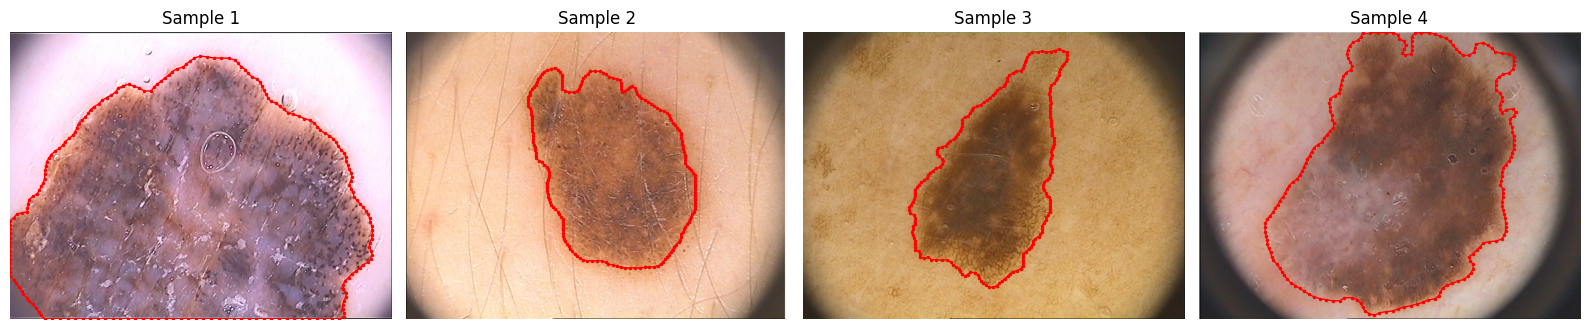

In [36]:

for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  # Wird (16, 3, 576, 766) sein
    print("Punkt-Batch Form:", batch_points.shape) # Wird (16, 200, 2) sein
    
    # Plot aufrufen
    verify_dataset(batch_images, batch_points)
    break # Bricht nach dem ersten Batch ab

: 